In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_test = pd.read_csv("data/tatatest.csv")

In [3]:
df_test.Date = pd.to_datetime(df_test['Date'])
df_test = df_test.sort_values('Date').reset_index(drop=True)

In [4]:
df_test.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2017-01-02,122.80,124.20,121.35,123.55,123.55,1102178,1354.06
1,2017-01-03,122.80,125.40,122.80,124.75,124.45,580430,721.93
2,2017-01-04,125.00,126.05,123.80,124.10,124.45,656213,818.98
3,2017-01-05,124.75,125.65,124.55,125.30,125.20,503565,630.23
4,2017-01-06,125.40,126.95,124.05,124.50,124.65,1255021,1573.67


In [5]:
# Base Returns & Lagged Signals
df_test["Daily_Return"] = (
    100 * (df_test["Close"] - df_test["Close"].shift(1)) / df_test["Close"].shift(1)
)
df_test["Intraday_Return"] = (df_test["Close"] - df_test["Open"]) / df_test["Open"]
df_test["Daily_Range"] = (df_test["High"] - df_test["Low"]) / df_test["Low"]

df_test["Return_Lag1"] = df_test["Daily_Return"].shift(1)
df_test["Return_Lag2"] = df_test["Daily_Return"].shift(2)
df_test["Return_Lag3"] = df_test["Daily_Return"].shift(3)
df_test["Return_Lag4"] = df_test["Daily_Return"].shift(4)
df_test["Return_Lag5"] = df_test["Daily_Return"].shift(5)

# Multi-Horizon Momentum & RSI
df_test["Return_5D"] = (
    100 * (df_test["Close"] - df_test["Close"].shift(5)) / df_test["Close"].shift(5)
)
df_test["Return_10D"] = (
    100 * (df_test["Close"] - df_test["Close"].shift(10)) / df_test["Close"].shift(10)
)

delta = df_test["Close"].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df_test["RSI_14"] = 100 - (100 / (1 + (gain / (loss + 1e-9))))

# Moving Average Ratios (Trend Alignment)
df_test["Close_to_MA10"] = df_test["Close"] / df_test["Close"].rolling(10).mean()
df_test["Close_to_MA50"] = df_test["Close"] / df_test["Close"].rolling(50).mean()
df_test["MA10_to_MA50"] = (
    df_test["Close"].rolling(10).mean() / df_test["Close"].rolling(50).mean()
)

# Volatility & Regime Shifts
df_test["Volatility10"] = df_test["Daily_Return"].rolling(10).std()
df_test["Volatility30"] = df_test["Daily_Return"].rolling(30).std()
df_test["Vol_Ratio_10_30"] = df_test["Volatility10"] / (df_test["Volatility30"] + 1e-9)

# Volume & VWAP Ratios
df_test["Turnover_to_MA10"] = df_test["Turnover (Lacs)"] / df_test[
    "Turnover (Lacs)"
].rolling(10).mean()
df_test["Volume_to_MA10"] = df_test["Total Trade Quantity"] / df_test[
    "Total Trade Quantity"
].rolling(10).mean()
df_test["Volume_Lag1"] = df_test["Total Trade Quantity"] / df_test[
    "Total Trade Quantity"
].shift(1)

# Raw VWAP calculation (keep VWAP out of X_train, use only Close_to_VWAP)
df_test["VWAP"] = (df_test["Turnover (Lacs)"] * 100000) / df_test["Total Trade Quantity"]
df_test["Close_to_VWAP"] = df_test["Close"] / df_test["VWAP"]

# Candlestick Anatomy
hl_span = (df_test["High"] - df_test["Low"]) + 1e-9
df_test["Close_Location"] = (df_test["Close"] - df_test["Low"]) / hl_span
df_test["Upper_Shadow_Ratio"] = (
    df_test["High"] - df_test[["Open", "Close"]].max(axis=1)
) / hl_span
df_test["Lower_Shadow_Ratio"] = (
    df_test[["Open", "Close"]].min(axis=1) - df_test["Low"]
) / hl_span

# Target Setup
df_test["Target_Return"] = df_test["Daily_Return"].shift(-1)
df_test["Target_Class"] = (df_test["Target_Return"] > 0).astype(int)

# #rule : no absolute values so model doesnt cheat


In [6]:
df_test.dropna(inplace=True)
df_test.reset_index(inplace=True,drop=True)


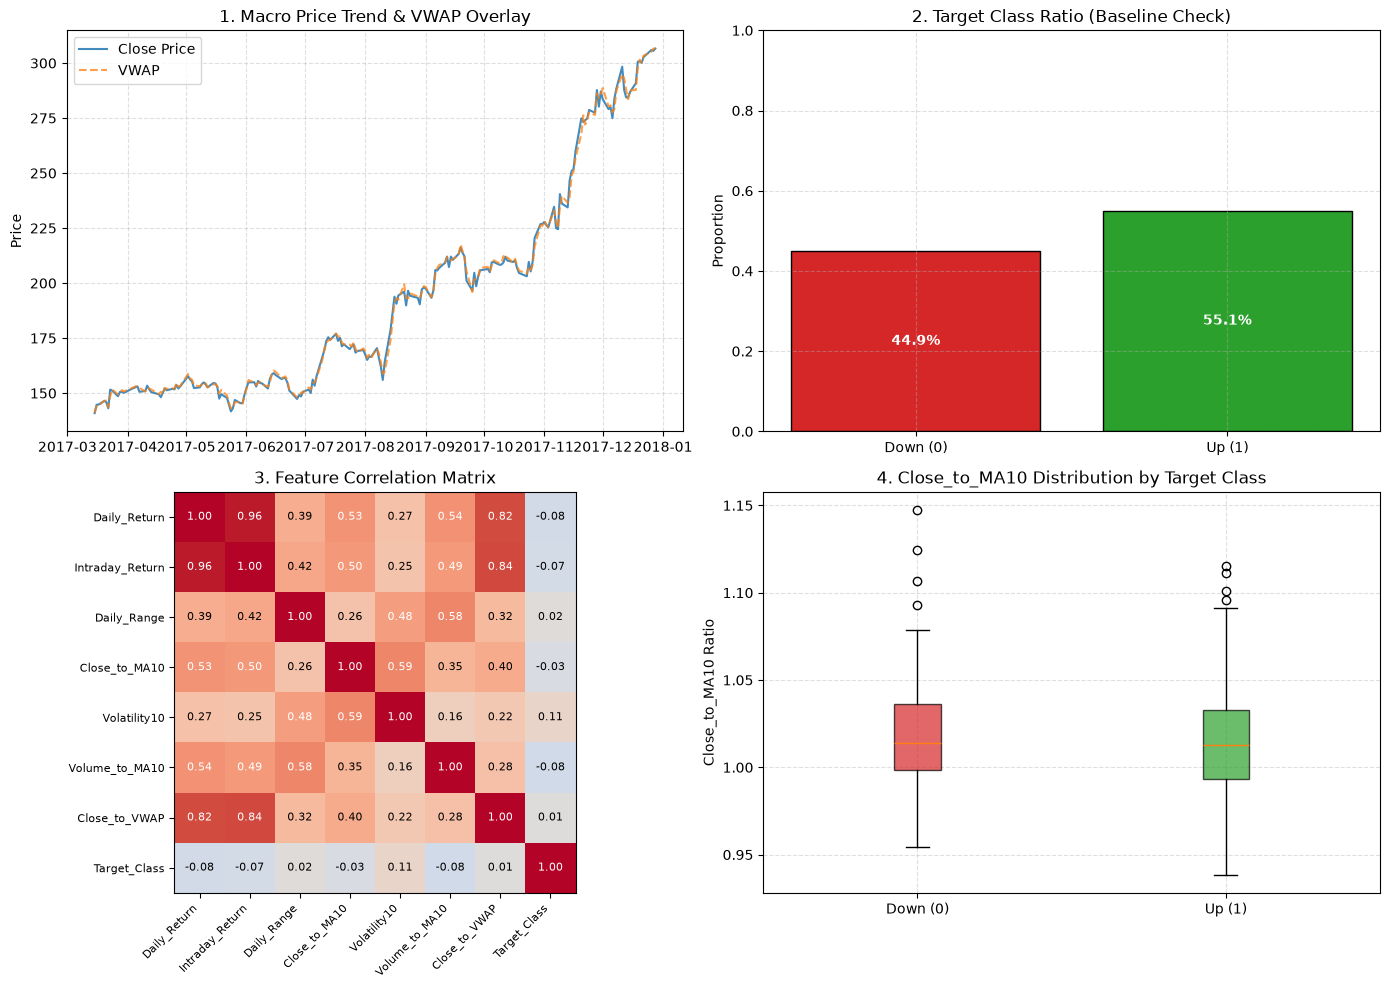

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Macro Price Trend & VWAP Overlay
axes[0, 0].plot(
    df_test["Date"], df_test["Close"], label="Close Price", color="tab:blue", alpha=0.85
)
axes[0, 0].plot(
    df_test["Date"],
    df_test["VWAP"],
    label="VWAP",
    color="tab:orange",
    linestyle="--",
    alpha=0.75,
)
axes[0, 0].set_title("1. Macro Price Trend & VWAP Overlay")
axes[0, 0].set_ylabel("Price")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle="--", alpha=0.4)

# 2. Target Class Ratio (Baseline Check)
class_counts = df_test["Target_Class"].value_counts(normalize=True)
bars = axes[0, 1].bar(
    ["Down (0)", "Up (1)"],
    [class_counts.get(0, 0), class_counts.get(1, 0)],
    color=["tab:red", "tab:green"],
    edgecolor="black",
)
axes[0, 1].set_title("2. Target Class Ratio (Baseline Check)")
axes[0, 1].set_ylabel("Proportion")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, linestyle="--", alpha=0.4)

for bar in bars:
    yval = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2.0,
        yval / 2,
        f"{yval:.1%}",
        ha="center",
        va="center",
        color="white",
        weight="bold",
    )

# 3. Feature Correlation Heatmap (Pure Matplotlib)
key_cols = [
    "Daily_Return",
    "Intraday_Return",
    "Daily_Range",
    "Close_to_MA10",
    "Volatility10",
    "Volume_to_MA10",
    "Close_to_VWAP",
    "Target_Class",
]
corr = df_test[key_cols].corr().values
im = axes[1, 0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

axes[1, 0].set_xticks(range(len(key_cols)))
axes[1, 0].set_yticks(range(len(key_cols)))
axes[1, 0].set_xticklabels(key_cols, rotation=45, ha="right", fontsize=8)
axes[1, 0].set_yticklabels(key_cols, fontsize=8)
axes[1, 0].set_title("3. Feature Correlation Matrix")

# Annotate correlation values inside heat cells
for i in range(len(key_cols)):
    for j in range(len(key_cols)):
        val = corr[i, j]
        text_color = "white" if abs(val) > 0.45 else "black"
        axes[1, 0].text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
        )

# 4. Feature Separation (Boxplot of Close_to_MA10 by Class)
down_vals = df_test[df_test["Target_Class"] == 0]["Close_to_MA10"].dropna()
up_vals = df_test[df_test["Target_Class"] == 1]["Close_to_MA10"].dropna()

bp = axes[1, 1].boxplot(
    [down_vals, up_vals],
    patch_artist=True,
    tick_labels=["Down (0)", "Up (1)"],
)
colors = ["tab:red", "tab:green"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 1].set_title("4. Close_to_MA10 Distribution by Target Class")
axes[1, 1].set_ylabel("Close_to_MA10 Ratio")
axes[1, 1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [8]:
X_test = df_test.drop(columns=[
    'Target_Class', 'Target_Return',
    'Date', 'Open', 'High', 'Low', 'Last', 'Close',
    'Total Trade Quantity', 'Turnover (Lacs)','VWAP'
])
y_test = df_test["Target_Class"]

In [9]:
from joblib import load,dump
scaler = load("feature_scaler.joblib")
scaled_X_test = scaler.transform(X_test)

## importing the models

In [10]:
from joblib import load,dump
clf_knn = load("clf_knn.joblib")
clf_ridge = load("clf_ridge.joblib")
clf_log = load("clf_log.joblib")

In [11]:
from sklearn.metrics import accuracy_score, f1_score, precision_score

def show_scores(model):
    test_preds = model.predict(scaled_X_test)
    scores = {
        "Test Accuracy": accuracy_score(y_test, test_preds),
        "Test Precision": precision_score(y_test, test_preds),
        "Test F1": f1_score(y_test, test_preds),
    }
    return scores

In [12]:
show_scores(clf_knn)

{'Test Accuracy': 0.6868686868686869,
 'Test Precision': 0.7326732673267327,
 'Test F1': 0.7047619047619048}

In [13]:
show_scores(clf_ridge)

{'Test Accuracy': 0.5202020202020202,
 'Test Precision': 0.6296296296296297,
 'Test F1': 0.4171779141104294}

In [14]:
show_scores(clf_log)

{'Test Accuracy': 0.5202020202020202,
 'Test Precision': 0.6296296296296297,
 'Test F1': 0.4171779141104294}

## only KNN overshoots the baseline 55.1% up accuracy so it is the most suitable model

## advanced knn evaluation metrics 

In [15]:
from sklearn.metrics import (
    confusion_matrix,
    log_loss,
    matthews_corrcoef,
    recall_score,
    roc_auc_score,
)

# Probabilities for positive class (Up)
y_probs_knn = clf_knn.predict_proba(scaled_X_test)[:, 1]
y_preds_knn = clf_knn.predict(scaled_X_test)

# Advanced ML Metrics
print("=== Advanced KNN Metrics ===")
print(f"Recall (Sensitivity): {recall_score(y_test, y_preds_knn):.2%}")
print(f"ROC-AUC Score       : {roc_auc_score(y_test, y_probs_knn):.4f}")
print(f"MCC Score           : {matthews_corrcoef(y_test, y_preds_knn):.4f}")
print(f"Log Loss            : {log_loss(y_test, y_probs_knn):.4f}\n")

# Confusion Matrix Breakdown
tn, fp, fn, tp = confusion_matrix(y_test, y_preds_knn).ravel()
print(f"True Positives  : {tp}")
print(f"False Positives : {fp}")
print(f"True Negatives  : {tn}")
print(f"False Negatives : {fn}")

=== Advanced KNN Metrics ===
Recall (Sensitivity): 67.89%
ROC-AUC Score       : 0.7160
MCC Score           : 0.3737
Log Loss            : 1.7883

True Positives  : 74
False Positives : 27
True Negatives  : 62
False Negatives : 35
